# Fully Connected Autoencoder with SWaT Dataset 2020

In [77]:
import pandas as pd
import numpy as np

df = pd.read_csv("SWaT_cleaned_data_2020.csv")

print(df.shape)
df.head()

(32402, 61)


,P206.Status,MV501.Status,P203.Status,MV302.Status,MV101.Status,P4_STATE,P101.Status,P404.Status,P402.Status,P204.Status,...,AIT504.Pv,DPIT301.Pv,LIT401.Pv,LIT301.Pv,P1_STATE,FIT502.Pv,P502.Status,MV201.Status,P302.Status,P6_STATE
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.345552,3.755042,830.479400,1008.27515,1.0,0.002562,1.0,1.0,1.0,1.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.345552,3.755042,830.556300,1008.47540,1.0,0.002562,1.0,1.0,1.0,1.0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.345552,3.755042,830.440900,1008.47540,1.0,0.002562,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.653166,3.755042,830.979248,1008.47540,1.0,0.002562,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.653166,3.755042,830.594700,1008.47540,1.0,0.002562,1.0,1.0,1.0,1.0


In [78]:
timestamps = pd.to_datetime(df['t_stamp'], errors='coerce')
df = df.drop(columns=['t_stamp'])

## Verificar valores faltantes

In [79]:
df.isna().sum().sum()

np.int64(60)

In [80]:
df = df.ffill()
df.isna().sum().sum()

np.int64(0)

## Normalización

In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data_scaled = scaler.fit_transform(df)

data_scaled = pd.DataFrame(data_scaled, columns=df.columns)

## Crear ventanas temporales

Empezar con L = 60, stride = 5

In [82]:
def create_windows(data, window_size=60, stride=5):

    windows = []

    for i in range(0, len(data) - window_size, stride):
        window = data[i:i+window_size]
        windows.append(window)

    return np.array(windows)

In [83]:
windows = create_windows(data_scaled.values, window_size=60, stride=5)

print(windows.shape)

(6469, 60, 60)


## División Train/Test

In [84]:
from sklearn.model_selection import train_test_split

train_windows, test_windows = train_test_split(
    windows,
    test_size=0.3,
    shuffle=True,
    random_state=42
)

print(train_windows.shape)
print(test_windows.shape)

(4528, 60, 60)
(1941, 60, 60)


## Aplanar ventanas para FC Autoencoder

In [85]:
n_train, L, n_features = train_windows.shape
X_train = train_windows.reshape(n_train, L * n_features)

n_test = test_windows.shape[0]
X_test = test_windows.reshape(n_test, L * n_features)

print(X_train.shape)
print(X_test.shape)

(4528, 3600)
(1941, 3600)


## Convertir a PyTorch

In [86]:
import torch
from torch.utils.data import DataLoader, TensorDataset

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

## Implementación FC Autoencoder

In [87]:
import torch.nn as nn

class FCAutoencoder(nn.Module):

    def __init__(self, input_dim):

        super(FCAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, input_dim)
        )

    def forward(self, x):

        z = self.encoder(x)
        x_hat = self.decoder(z)

        return x_hat

In [88]:
input_dim = X_train.shape[1]

model = FCAutoencoder(input_dim)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

## Definición de entrenamiento

In [89]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 30

## Entrenamiento

In [90]:
loss_history = []

for epoch in range(epochs):

    total_loss = 0

    for batch in train_loader:

        x = batch[0].to(device)

        optimizer.zero_grad()

        x_hat = model(x)

        loss = criterion(x_hat, x)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    epoch_loss = total_loss / len(train_loader)
    loss_history.append(epoch_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss}")

Epoch 1/30, Loss: 0.30230926061180274
Epoch 2/30, Loss: 0.12770008739136474
Epoch 3/30, Loss: 0.10847725645757057
Epoch 4/30, Loss: 0.08423468360388783
Epoch 5/30, Loss: 0.07935848087072372
Epoch 6/30, Loss: 0.07234734540778986
Epoch 7/30, Loss: 0.068326467556328
Epoch 8/30, Loss: 0.06494824783745366
Epoch 9/30, Loss: 0.060243439886876395
Epoch 10/30, Loss: 0.0661398394584236
Epoch 11/30, Loss: 0.06196757227602139
Epoch 12/30, Loss: 0.05757294256817287
Epoch 13/30, Loss: 0.05486774999438457
Epoch 14/30, Loss: 0.05518307563074878
Epoch 15/30, Loss: 0.05281850194532267
Epoch 16/30, Loss: 0.055966185983008065
Epoch 17/30, Loss: 0.05485360345370333
Epoch 18/30, Loss: 0.055879927712531995
Epoch 19/30, Loss: 0.05442869204135848
Epoch 20/30, Loss: 0.054415886801942974
Epoch 21/30, Loss: 0.05139668540320766
Epoch 22/30, Loss: 0.045355965278413096
Epoch 23/30, Loss: 0.04754454294927943
Epoch 24/30, Loss: 0.051512327504304935
Epoch 25/30, Loss: 0.047542101546177565
Epoch 26/30, Loss: 0.045323204

## Curva de entrenamiento

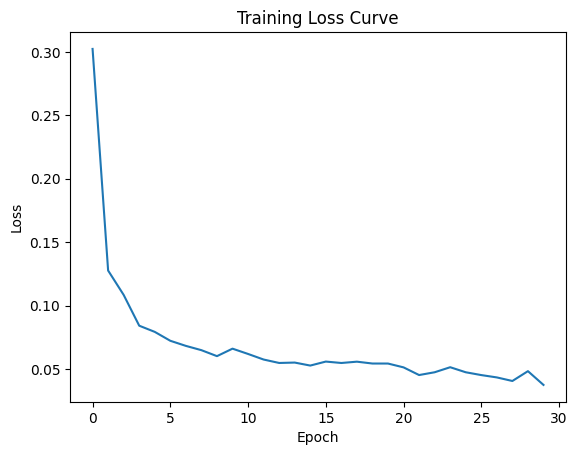

In [91]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

## Error de reconstrucción

In [92]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

model.eval()

reconstruction_errors = []

with torch.no_grad():

    x = X_test_tensor.to(device)

    x_hat = model(x)

    error = torch.mean((x - x_hat)**2, dim=1)

    reconstruction_errors = error.cpu().numpy()

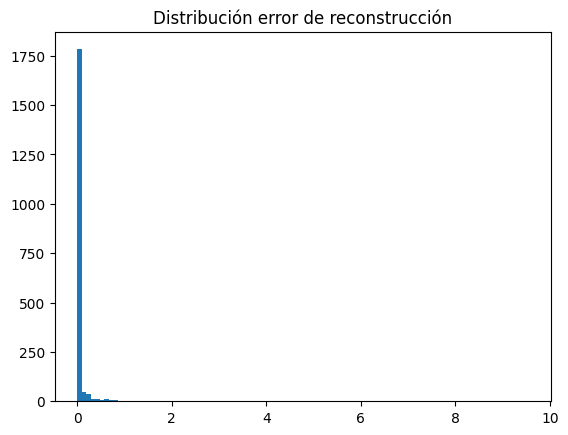

In [93]:
plt.hist(reconstruction_errors, bins=100)
plt.title("Distribución error de reconstrucción")
plt.show()

## Percentiles

In [94]:
np.percentile(reconstruction_errors, [90,95,97.5,99])

array([0.06751429, 0.22174148, 0.51496893, 0.91345439])

## Cálculo de FAR

In [95]:
model.eval()

train_reconstruction_errors = []

with torch.no_grad():
    x_train = X_train_tensor.to(device)
    x_train_hat = model(x_train)

    train_error = torch.mean((x_train - x_train_hat)**2, dim=1)
    train_reconstruction_errors = train_error.cpu().numpy()

In [96]:
tau_95 = np.percentile(train_reconstruction_errors, 95)
tau_975 = np.percentile(train_reconstruction_errors, 97.5)
tau_99 = np.percentile(train_reconstruction_errors, 99)

print("tau_95 =", tau_95)
print("tau_97.5 =", tau_975)
print("tau_99 =", tau_99)

tau_95 = 0.13094577
tau_97.5 = 0.26172665
tau_99 = 0.42620337


In [97]:
far_95 = np.mean(reconstruction_errors > tau_95)
far_975 = np.mean(reconstruction_errors > tau_975)
far_99 = np.mean(reconstruction_errors > tau_99)

print("FAR @ P95:", far_95)
print("FAR @ P97.5:", far_975)
print("FAR @ P99:", far_99)

FAR @ P95: 0.07006697578567748
FAR @ P97.5: 0.04482225656877898
FAR @ P99: 0.030911901081916538


In [98]:
print("FAR @ P95:", far_95 * 100, "%")
print("FAR @ P97.5:", far_975 * 100, "%")
print("FAR @ P99:", far_99 * 100, "%")

FAR @ P95: 7.006697578567748 %
FAR @ P97.5: 4.482225656877898 %
FAR @ P99: 3.091190108191654 %
